In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import xgboost as xgb

#### 1. Load the Data

In [3]:
df = pd.read_csv(r"C:\Users\PRITHEW\Downloads\ford_stock_prices_1986_to_alliance.csv")
data = df[['Close']].values

In [4]:
df.head()

,Date,Open,High,Low,Close,Volume
0,02-01-1986,0.794812,0.803452,0.791356,0.794812,7398223
1,03-01-1986,0.798268,0.803452,0.784445,0.789629,7653050
2,06-01-1986,0.789629,0.789629,0.779262,0.786173,3579096
3,07-01-1986,0.787901,0.799996,0.787901,0.798268,5824867
4,08-01-1986,0.799996,0.803452,0.770623,0.772351,7256834


In [5]:
df.shape

(9803, 6)

#### 2. Scaling the Data

In [6]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

#### 3. Creating the sequence

In [7]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

SEQ_LEN = 150
X, y = create_sequences(scaled_data, SEQ_LEN)
X = X.reshape((X.shape[0], X.shape[1], 1))

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

#### 4. Training the LSTM Model

In [8]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(SEQ_LEN,1)))
lstm_model.add(LSTM(50))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

c:\Users\PRITHEW\Desktop\Machine_Learning\my_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - loss: 0.0014
Epoch 2/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - loss: 2.2914e-04
Epoch 3/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 1.9438e-04
Epoch 4/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - loss: 1.7347e-04
Epoch 5/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - loss: 1.5679e-04
Epoch 6/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - loss: 1.3529e-04
Epoch 7/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - loss: 1.2354e-04
Epoch 8/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - loss: 1.1995e-04
Epoch 9/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - loss: 1.1751e-04
Epoch 10/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - loss: 1.0047e-04
Epoch 11/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 8.9972e-05
Epoch 12/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 8.7908e-05
Epoch 13/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 8.3139e-05
Epoch 14/100
242/242 ━━━━━━━━━━━━━━━━━

#### 5. LSTM Predictions

In [9]:
lstm_train_preds = lstm_model.predict(X_train)
lstm_test_preds = lstm_model.predict(X_test)

242/242 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


#### 6. Train XGBoost on Original Features
#### Use previous SEQ_LEN scaled prices as features

In [10]:
X_train_xgb = X_train.reshape(X_train.shape[0], SEQ_LEN)
X_test_xgb = X_test.reshape(X_test.shape[0], SEQ_LEN)

xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=10,subsample=0.8, colsample_bytree=0.8)
xgb_model.fit(X_train_xgb, y_train)
xgb_test_preds = xgb_model.predict(X_test_xgb)

#### 7. Hybrid via Weighted Average
#### You can tune weights for best R²

In [11]:
hybrid_test_preds = 0.6 * lstm_test_preds.reshape(-1) + 0.4 * xgb_test_preds

#### Rescale predictions

In [12]:
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1,1))
lstm_test_rescaled = scaler.inverse_transform(lstm_test_preds)
xgb_test_rescaled = scaler.inverse_transform(xgb_test_preds.reshape(-1,1))
hybrid_test_rescaled = scaler.inverse_transform(hybrid_test_preds.reshape(-1,1))

#### 8. Evaluate

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

def print_metrics(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.4f}, R²: {r2:.4f}")

print_metrics(y_test_rescaled, lstm_test_rescaled, "LSTM")
print_metrics(y_test_rescaled, xgb_test_rescaled, "XGBoost")
print_metrics(y_test_rescaled, hybrid_test_rescaled, "Hybrid LSTM+XGBoost")

LSTM -> RMSE: 0.2642, R²: 0.9910
XGBoost -> RMSE: 0.6108, R²: 0.9518
Hybrid LSTM+XGBoost -> RMSE: 0.3657, R²: 0.9827


#### 9. Plot Comparison

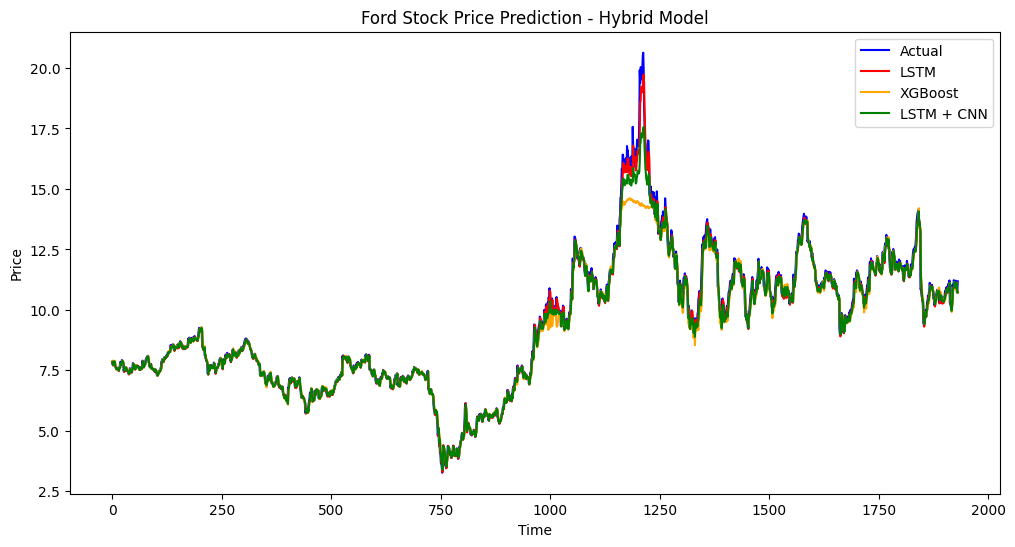

In [14]:
plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled, color='blue', label='Actual')
plt.plot(lstm_test_rescaled, color='red', label='LSTM')
plt.plot(xgb_test_rescaled, color='orange', label='XGBoost')
plt.plot(hybrid_test_rescaled, color='green', label='LSTM + CNN')
plt.title("Ford Stock Price Prediction - Hybrid Model")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

#### 10. Predicting Future Stock Price

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Predicted Prices for next 12 days:
Day 1: 11.09
Day 2: 11.02
Day 3: 10.91
Day 4: 10.85
Day 5: 10.82
Day 6: 10.78
Day 7: 10.73
Day 8: 10.69
Day 9: 10.66
Day 10: 10.68
Day 11: 10.66
Day 12: 10.71


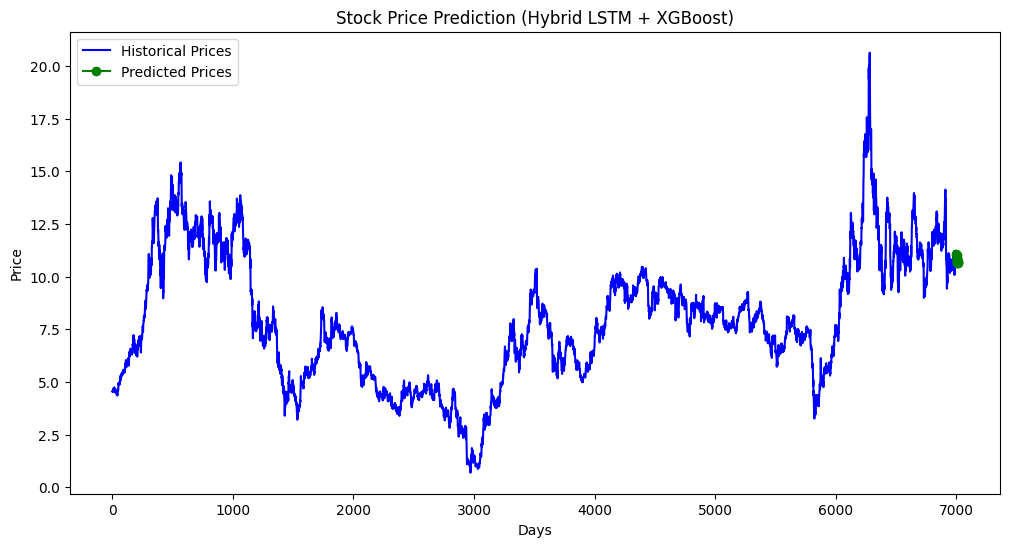

In [15]:
future_days = int(input("Enter the number of days to predict: "))
predicted_prices = []

# Start with last SEQ_LEN days (scaled)
current_seq = scaled_data[-SEQ_LEN:].copy()  # shape: (SEQ_LEN,)

for _ in range(future_days):
    # Prepare LSTM input: (1, SEQ_LEN, 1)
    X_input = current_seq.reshape(1, SEQ_LEN, 1)
    
    # LSTM predicts next step (scaled)
    lstm_next_scaled = lstm_model.predict(X_input)[0][0]
    
    # Prepare XGBoost input: last SEQ_LEN scaled prices
    xgb_input = current_seq.reshape(1, SEQ_LEN)
    xgb_next_scaled = xgb_model.predict(xgb_input)[0]
    
    # Hybrid weighted average
    hybrid_next_scaled = 0.6 * lstm_next_scaled + 0.4 * xgb_next_scaled
    
    # Rescale to original price
    next_day_price = scaler.inverse_transform(np.array([[hybrid_next_scaled]]))[0][0]
    predicted_prices.append(next_day_price)
    
    # Update sequence for next prediction
    current_seq = np.append(current_seq[1:], hybrid_next_scaled)

# ------------------------------
# Print Predictions
# ------------------------------
print(f"\nPredicted Prices for next {future_days} days:")
for i, price in enumerate(predicted_prices, 1):
    print(f"Day {i}: {price:.2f}")

# ------------------------------
# Plot Predictions with Historical Data
# ------------------------------
historical_prices = scaler.inverse_transform(scaled_data[-7000:])  # last 7000 days

plt.figure(figsize=(12,6))
plt.plot(range(len(historical_prices)), historical_prices, color='blue', label='Historical Prices')
plt.plot(range(len(historical_prices), len(historical_prices)+future_days),
         predicted_prices, color='green', marker='o', label='Predicted Prices')
plt.title("Stock Price Prediction (Hybrid LSTM + XGBoost)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()